#### Facebook Prophet

1.  Facebook Prophet is a time series forecasting method that can automatically handle

    (a.)    trend

    (b.)    seasonality

    (c.)    holidays

    (d.)    missing values

    (e.)    outliers


#### Step 1: Import all the necessary libraries

In [1407]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    prophet         import  Prophet

#### OBSERVATIONS:

1.  Prophet ===============> It is a popular time series forecasting method that is used for handling the holidays

#### Step 2: Load the dataset

In [1408]:
#### Load the dataset

df = pd.read_csv('Airline_Passengers.csv')

In [1409]:
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


#### OBSERVATIONS:

1.  The above dataset represents the airline passengers dataset for each month starting from 1949 till 1960.

#### Step 3: Perform the Data Exploration

In [1410]:
#### get the first five rows of the dataset

df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [1411]:
#### get the last five rows of the dataset

df.tail()

,Month,Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [1412]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 144


In [1413]:
#### get the columns used in the dataset

df.columns

Index(['Month', 'Passengers'], dtype='object')

In [1414]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [1415]:
#### get the descriptive summary statistics about each column in the dataset

df.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [1416]:
#### get the descriptive summary statistics about each categorical column in the dataset

df.describe(include='object')

,Month
count,144
unique,144
top,1949-01
freq,1


#### Step 4: Perform Data Cleaning and Future Engineering

In [1417]:
#### Rename the columns of month to 'ds' and passengers to 'y' in the dataset

df.columns = ['ds','y']

In [1418]:
df

,ds,y
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


#### OBSERVATIONS:

1.  The month column has been renamed to 'ds' and the passenger column has been renamed to 'y' in the dataset.

In [1419]:
#### Convert the ds column of object type to datetime in the dataset

df['ds'] = pd.to_datetime(df['ds'])

In [1420]:
#### Again check the information about the columns in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      144 non-null    datetime64[ns]
 1   y       144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


#### OBSERVATIONS:

1.  The ds column of object type has been converted to datetime type.

In [1421]:
#### Check for the missing values in the dataset

df.isnull().sum()

ds    0
y     0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [1422]:
#### Check for the duplicate records in the dataset

df[df.duplicated()]

,ds,y


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

#### Step 5: Plot the Original Time Series data

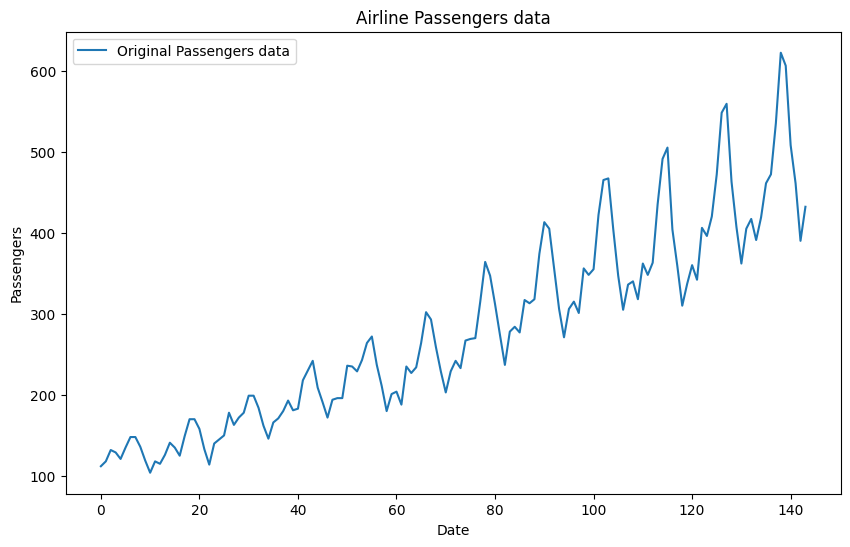

In [1423]:
plt.figure(figsize=(10,6))

#### plot the original time series
plt.plot(df.index, df['y'], label = 'Original Passengers data')
#### get the title of the graph
plt.title('Airline Passengers data')

#### get the x axis of the graph
plt.xlabel('Date')

#### get the y-axis of the graph
plt.ylabel('Passengers')

plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above dataset represents the airline passengers data from the year 1949 till 1960.

2.  The dataset represents 

    (a.)  increasing upward trend every year

    (b.)  seasonal repeated cycles every year

    (c.)  strong variations in the data.

3.  As trend, seasonality and variations in the data exists, so this dataset is perfect for Prophet.

#### Step 6: Create a model for Prophet

In [1424]:
from    prophet import  Prophet

#### Create an object for Prophet

model = Prophet()

#### OBSERVATIONS:

1.  A model has been created for Prophet to perform its time series forecasting operations.

2.  Default Prophet includes Trend + Yearly Seasonality + Weekly Seasonality + Daily Seasonality.

    (a.)     As the above dataset is a monthly data, so Weekly seasonality + Daily Seasonality has been excluded.

#### Step 7: Train the model

In [1425]:
#### Train the model

model.fit(df)

13:21:58 - cmdstanpy - INFO - Chain [1] start processing
13:21:58 - cmdstanpy - INFO - Chain [1] done processing


#### OBSERVATIONS:

1.  After performing the training of the model, Prophet decomposes the data into :---------------

    (a.)    Trends

    (b.)    Seasonality

    (c.)    Holiday effects

    (d.)    Outliers

#### Step 8: Create the Future Dates

In [1426]:
#### create the future dates

future_dates = model.make_future_dataframe(
    periods = 24                                    ,
    freq    = 'MS'
)

In [1427]:
future_dates.tail(24)

,ds
144,1961-01-01
145,1961-02-01
146,1961-03-01
147,1961-04-01
148,1961-05-01
149,1961-06-01
150,1961-07-01
151,1961-08-01
152,1961-09-01
153,1961-10-01


#### OBSERVATIONS:

1.  It creates the next 24 future dates for the starting dates of every month.

#### Step 9: Predict the forecasting of the next 24 months

In [1428]:
#### perform the prediction for the next 24 months

forecasted_values = model.predict(future_dates)

In [1429]:
forecasted_values

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,106.662351,55.259507,111.356690,106.662351,106.662351,-21.848235,-21.848235,-21.848235,-21.848235,-21.848235,-21.848235,0.0,0.0,0.0,84.814116
1,1949-02-01,108.835378,51.596917,109.966192,108.835378,108.835378,-30.607610,-30.607610,-30.607610,-30.607610,-30.607610,-30.607610,0.0,0.0,0.0,78.227768
2,1949-03-01,110.798112,79.793263,140.739719,110.798112,110.798112,-0.455867,-0.455867,-0.455867,-0.455867,-0.455867,-0.455867,0.0,0.0,0.0,110.342245
3,1949-04-01,112.971139,78.624023,135.132941,112.971139,112.971139,-5.160420,-5.160420,-5.160420,-5.160420,-5.160420,-5.160420,0.0,0.0,0.0,107.810719
4,1949-05-01,115.074068,81.771003,140.551272,115.074068,115.074068,-3.807959,-3.807959,-3.807959,-3.807959,-3.807959,-3.807959,0.0,0.0,0.0,111.266109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,1962-08-01,545.727815,584.186922,640.108909,544.455239,547.096869,67.693995,67.693995,67.693995,67.693995,67.693995,67.693995,0.0,0.0,0.0,613.421810
164,1962-09-01,548.845211,537.238060,595.161240,547.478028,550.322504,16.557980,16.557980,16.557980,16.557980,16.557980,16.557980,0.0,0.0,0.0,565.403191
165,1962-10-01,551.862045,502.751403,557.612563,550.416620,553.456866,-22.122002,-22.122002,-22.122002,-22.122002,-22.122002,-22.122002,0.0,0.0,0.0,529.740043
166,1962-11-01,554.979440,467.645556,524.847576,553.438390,556.662541,-58.131872,-58.131872,-58.131872,-58.131872,-58.131872,-58.131872,0.0,0.0,0.0,496.847568


#### OBSERVATIONS:

1.  The important columns produced by the forecasted vaues are as follows :----------------

    (a.)    ds ===============>  Date on which Prophet has performed the prediction

    (b.)    yhat =============>  predicted output produced by the Prophet

    (c.)    yhat_lower ========> lower bound of the predicted output

    (d.)    yhet_upper ========> upper bound of the predicted output

#### Step 10: View the Forecasted values

In [1430]:
forecasted_values[['ds','yhat','yhat_lower','yhat_upper']].tail(24)

,ds,yhat,yhat_lower,yhat_upper
144,1961-01-01,465.855801,438.721135,494.558019
145,1961-02-01,460.213822,431.560640,489.392030
146,1961-03-01,493.181277,462.738048,522.340313
147,1961-04-01,491.594119,464.610560,519.137943
148,1961-05-01,495.963414,466.830459,526.048675
149,1961-06-01,536.880562,506.583916,562.480506
150,1961-07-01,576.558689,550.002556,605.571712
151,1961-08-01,576.981536,549.697032,605.931305
152,1961-09-01,528.467130,501.270165,556.644489
153,1961-10-01,493.213015,464.579932,521.109152


#### OBSERVATIONS:

1.  It displays the forecasted values for the next 24 months.

#### Step 11: Plot the forecast

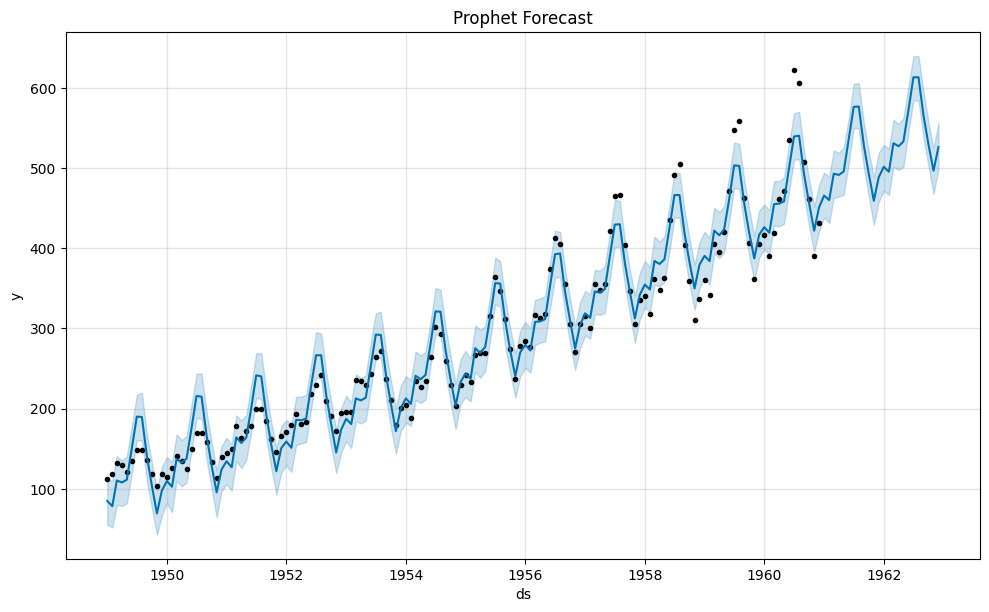

In [1431]:
fig1 = model.plot(forecasted_values)

#### give the title of the graph
plt.title('Prophet Forecast')

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above dataset represents the airline passengers data from 1949 till 1960.

2.  The blue line in the graph represents the forecasted line and it follows the upward trend in the graph.

3.  The light blue line represents the confidence interval in the graph.

#### Step 12: Plot the trend and seasonality

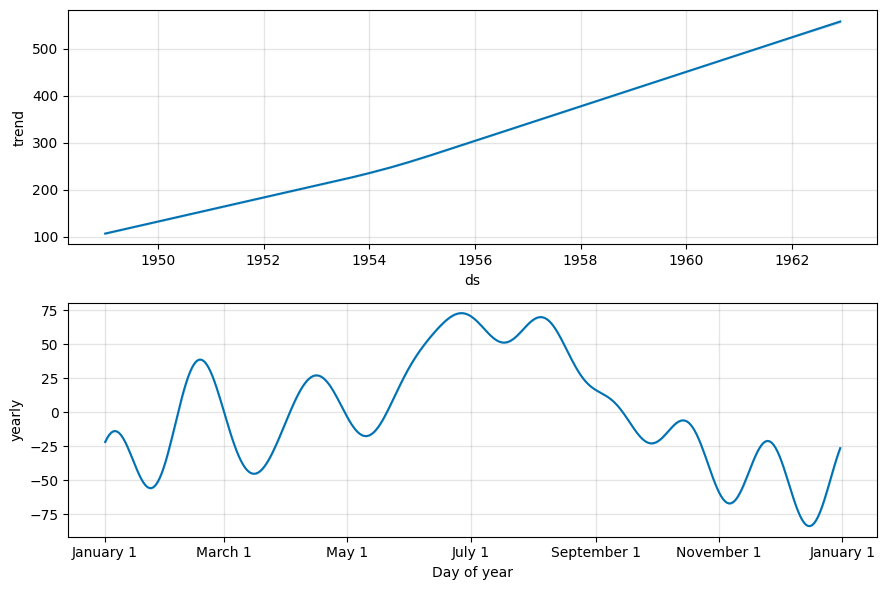

In [1432]:
fig2 = model.plot_components(forecasted_values)

plt.show()

#### OBSERVATIONS:

1.  Trend ===================>

    (a.)    The trend shows the linear curve moving in the upward direction meaning the number of airline passengers increases every year.

2.  Seasonality =============>

    (a.) The seasonality of the airline passengers is maximum during summer holidays and is minimum during winter holidays.

#### Step 13: Extract Only Future Forecast values

In [1433]:
#### Future Extracted values

future_forecasted_values = forecasted_values.tail(24)[['ds','yhat']]

In [1434]:
future_forecasted_values

,ds,yhat
144,1961-01-01,465.855801
145,1961-02-01,460.213822
146,1961-03-01,493.181277
147,1961-04-01,491.594119
148,1961-05-01,495.963414
149,1961-06-01,536.880562
150,1961-07-01,576.558689
151,1961-08-01,576.981536
152,1961-09-01,528.467130
153,1961-10-01,493.213015


#### OBSERVATIONS:

1.  The above data represents the future dates for the next 24 months along with their predicted values.

#### Step 14: Plot the Actual vs Forecasted values

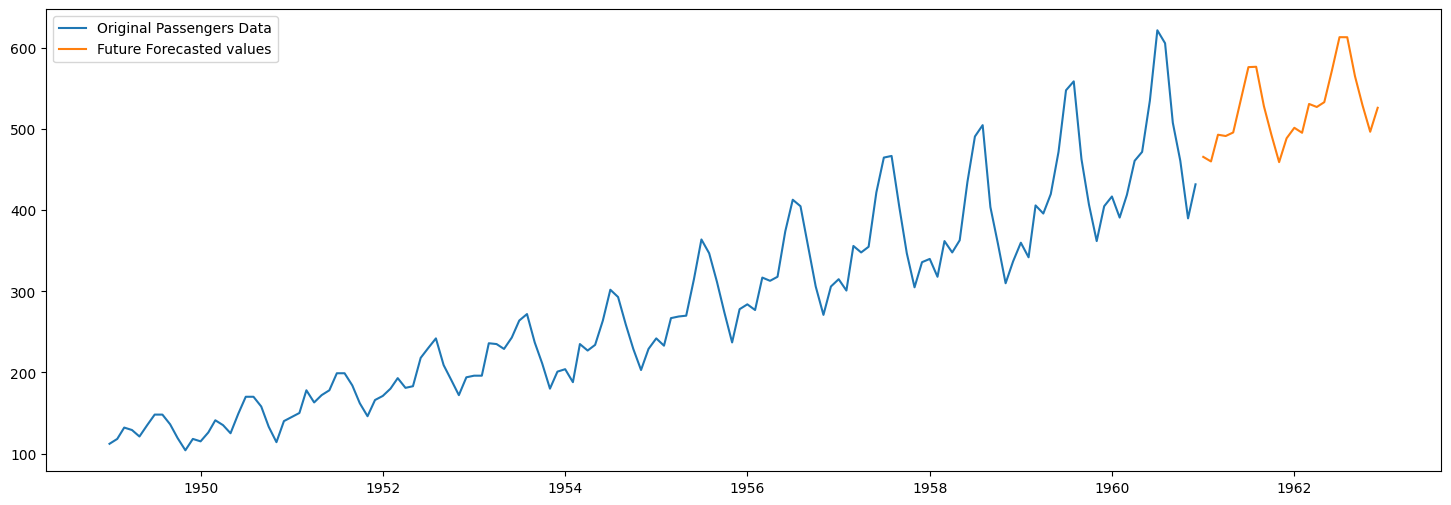

In [1435]:
plt.figure(figsize=(18,6))

#### plot the actual data points
plt.plot(df['ds'], df['y'],label = 'Original Passengers Data')

#### plot the predicted or the forecasted data points
plt.plot(future_forecasted_values['ds'],future_forecasted_values['yhat'], label = 'Future Forecasted values')

plt.legend()

plt.show()

#### OBSERVATIONS:

1.  From the above graph, we can see that the future forecasted values shows the same upwards trend and the seasonality.

2.  So from this it is concluded that the Prophet model captures the trend and seasonality in the data.

#### Step 15: Perform the Train Test Validation

In [1436]:
#### Divide the dataset into training and testing data

train = df.iloc[:-24]

test  = df.iloc[-24:]

In [1437]:
train

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
115,1958-08-01,505
116,1958-09-01,404
117,1958-10-01,359
118,1958-11-01,310


In [1438]:
test

,ds,y
120,1959-01-01,360
121,1959-02-01,342
122,1959-03-01,406
123,1959-04-01,396
124,1959-05-01,420
125,1959-06-01,472
126,1959-07-01,548
127,1959-08-01,559
128,1959-09-01,463
129,1959-10-01,407


#### OBSERVATIONS:

1.  The training data contains the airline passengers from 1949 till 1958 and the testing data represents the airline passengers from 1959 till 1960.

#### Step 16: Train the model

In [1439]:
#### Train the model

model = Prophet()

model.fit(train)

13:22:00 - cmdstanpy - INFO - Chain [1] start processing
13:22:00 - cmdstanpy - INFO - Chain [1] done processing


#### OBSERVATIONS:

1.  Another object instance for Prophet model is created.

2.  Then the model is trained using the training data.

#### Step 17: Create the future dates for the forecasted values

In [1440]:
#### Create the future dates

future = model.make_future_dataframe(
    periods = 24                    ,
    freq    = 'MS'
)

In [1441]:
future.tail(10)

,ds
134,1960-03-01
135,1960-04-01
136,1960-05-01
137,1960-06-01
138,1960-07-01
139,1960-08-01
140,1960-09-01
141,1960-10-01
142,1960-11-01
143,1960-12-01


#### Step 18: Perform the forecasting 

In [1442]:
forecasted = model.predict(future)

In [1443]:
forecasted[['ds','yhat']]

,ds,yhat
0,1949-01-01,88.455746
1,1949-02-01,83.099174
2,1949-03-01,117.588779
3,1949-04-01,110.091701
4,1949-05-01,111.280205
...,...,...
139,1960-08-01,521.787299
140,1960-09-01,482.138155
141,1960-10-01,449.809109
142,1960-11-01,421.615207


#### OBSERVATIONS:

1.  We have performed the forecasting of all the airline passengers from 1959 till 1960 for the last 24 months.

In [1444]:
test['y']

120    360
121    342
122    406
123    396
124    420
125    472
126    548
127    559
128    463
129    407
130    362
131    405
132    417
133    391
134    419
135    461
136    472
137    535
138    622
139    606
140    508
141    461
142    390
143    432
Name: y, dtype: int64

In [1445]:
forecasted['yhat'].iloc[-24:]

120    390.181602
121    387.654442
122    418.726448
123    412.772360
124    417.451197
125    452.337521
126    486.985391
127    484.690327
128    447.161467
129    414.908463
130    386.056627
131    413.114542
132    425.269062
133    423.730079
134    457.222236
135    450.247025
136    450.870344
137    489.491725
138    518.254197
139    521.787299
140    482.138155
141    449.809109
142    421.615207
143    447.879442
Name: yhat, dtype: float64

#### Step 19: Calculate the RMSE

In [1446]:
from sklearn.metrics import root_mean_squared_error

#### Calculate the error 

rmse = root_mean_squared_error(test['y'], forecasted['yhat'].iloc[-24:])

print("Root Mean Squared error of the model is:", rmse)

Root Mean Squared error of the model is: 40.39838464877204


#### OBSERVATIONS:

1.  The Prophet model achieved an RMSE of 40.40 on the test dataset. 

2.  This indicates that the forecasted passenger counts differ from the actual values by approximately 40 passengers on average. 

3.  Considering that the passenger volume ranges between 350 and 620 passengers, the model demonstrates reasonably good forecasting performance and successfully captures the overall trend and seasonality of the data.